In [1]:
import sys
import os

module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

In [2]:
import numpy as np 
import scipy as sp
from matplotlib import pyplot as plt
from utils.ETD_solver import etd_solve, cheb

Use ETD to numerically approximate the solution to the 1D heat equation: 
$$u_t = \nu u_{xx}$$
for $x \in (-1, 1)$, subject to homogenous Dirichlet boundary conditions $u(-1, t) = u(1, t) = 0$, and initial condition $u(x, 0) = \cos{(\frac{\pi x}{2})}$. Use $\nu = 1$. 

In [3]:
f = lambda x: np.cos(np.pi * x / 2)                     # initial condition function
nu = 1.                                                 # diffusion coefficient
T = 1.                                                  # final time value
nx = 100                                                # number of spatial steps
nt = 100                                                # number of time steps 

x_vals, dx = np.linspace(-1, 1, nx, retstep=True)       # generate spatial grid
D2 = (                                                  # build difference matrix for second derivative
    np.diag(np.ones(nx) * -2., 0) + 
    np.diag(np.ones(nx-1) * 1., -1) + 
    np.diag(np.ones(nx-1) * 1., 1)
) / dx**2
L = nu * D2

u0 = f(x_vals)                                          # evaluate initial condition on spatial grid

U, t_vals = etd_solve(L, u0, T, nt)                     # call numerical solver

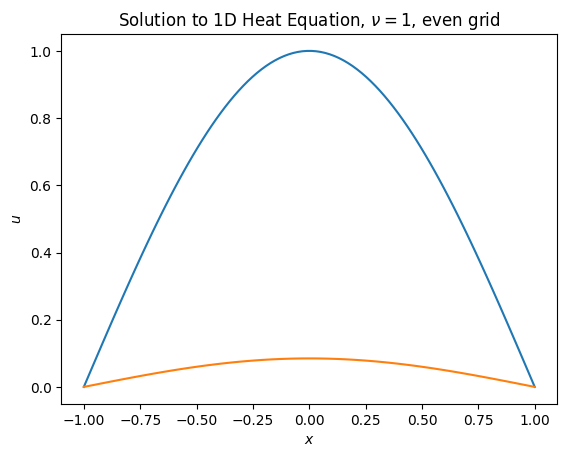

In [4]:
plt.plot(x_vals, U[0], label="Initial Time")
plt.plot(x_vals, U[-1], label="Final Time")
plt.xlabel(r"$x$")
plt.ylabel(r"$u$")
plt.title(r"Solution to 1D Heat Equation, $\nu = 1$, even grid")
plt.show()

In [5]:
f = lambda x: np.cos(np.pi * x / 2)         # initial condition function
nu = 1.                                     # diffusion coefficient
T = 1.                                      # final time value
nx = 32                                     # number of spatial steps
nt = 100                                    # number of time steps 

D, x_vals = cheb(nx)                        # use Chebyshev differencing matrix since solving on (-1, 1)
L = nu * D @ D                              # linear operator = nu * second derivative 

u0 = f(x_vals)                              # evaluate initial condition on spatial grid

U, t_vals = etd_solve(L, u0, T, nt)         # call numerical solver

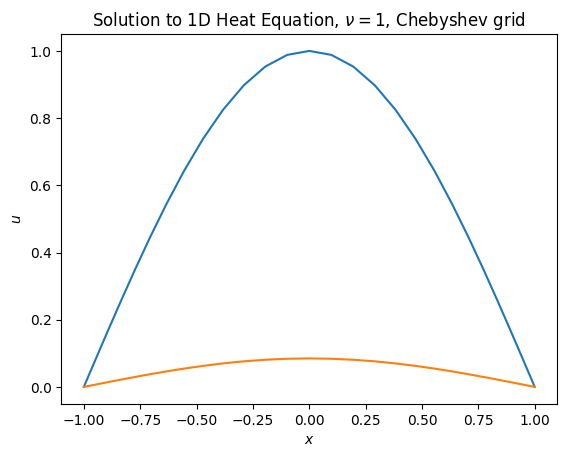

In [6]:
plt.plot(x_vals, U[0], label="Initial Time")
plt.plot(x_vals, U[-1], label="Final Time")
plt.xlabel(r"$x$")
plt.ylabel(r"$u$")
plt.title(r"Solution to 1D Heat Equation, $\nu = 1$, Chebyshev grid")
plt.show()